# Project 1: Numerical Methods for PDEs

**Author:** LAN,Tianwei  
**Student ID:** 21230969  
**Email:** tlanaa@connect.ust.hk

---

Contents:
- Part 1: heat equation on `[-1, 1]`
- Part 2: linear advection on `[-2, 2]`
- required plots and short summaries for each part

## Part 1: Heat Equation

Part 1 considers

$$
\frac{\partial u}{\partial t} = a\frac{\partial^2 u}{\partial x^2}, \quad -1 < x < 1, \quad a=2,
$$
with boundary conditions $u(-1,t)=u(1,t)=0$ and the given piecewise initial condition.

The spatial grid uses `J=20`, so `dx=0.1`. For each method, the solution is plotted at
$t = 0, dt, 25dt, 50dt$ for $dt = 0.0025$ and $dt = 0.0026$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

A = 2.0
J = 20
DX_HEAT = 0.1
HEAT_DTS = [0.0025, 0.0026]
HEAT_TARGET_STEPS = [0, 1, 25, 50]


def heat_initial_condition(x):
    x = np.asarray(x)
    return np.where(x <= 0.5, (x + 1.0) / 3.0, 1.0 - x)


def thomas_algorithm(lower, diag, upper, rhs):
    lower = np.asarray(lower, dtype=float).copy()
    diag = np.asarray(diag, dtype=float).copy()
    upper = np.asarray(upper, dtype=float).copy()
    rhs = np.asarray(rhs, dtype=float).copy()

    n = len(diag)
    for i in range(1, n):
        factor = lower[i - 1] / diag[i - 1]
        diag[i] -= factor * upper[i - 1]
        rhs[i] -= factor * rhs[i - 1]

    solution = np.zeros(n)
    solution[-1] = rhs[-1] / diag[-1]
    for i in range(n - 2, -1, -1):
        solution[i] = (rhs[i] - upper[i] * solution[i + 1]) / diag[i]

    return solution


def run_heat_explicit(dt, J=J, a=A):
    dx = 2.0 / J
    x = np.linspace(-1.0, 1.0, J + 1)
    u = heat_initial_condition(x)
    u[0] = 0.0
    u[-1] = 0.0

    r = a * dt / dx**2
    snapshots = {0: u.copy()}

    for n in range(1, max(HEAT_TARGET_STEPS) + 1):
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + r * (u[2:] - 2.0 * u[1:-1] + u[:-2])
        u_new[0] = 0.0
        u_new[-1] = 0.0
        u = u_new
        if n in HEAT_TARGET_STEPS:
            snapshots[n] = u.copy()

    return x, snapshots, r


def run_heat_crank_nicolson(dt, J=J, a=A):
    dx = 2.0 / J
    x = np.linspace(-1.0, 1.0, J + 1)
    u = heat_initial_condition(x)
    u[0] = 0.0
    u[-1] = 0.0

    r = a * dt / dx**2
    interior_size = J - 1
    lower = -0.5 * r * np.ones(interior_size - 1)
    diag = (1.0 + r) * np.ones(interior_size)
    upper = -0.5 * r * np.ones(interior_size - 1)

    snapshots = {0: u.copy()}

    for n in range(1, max(HEAT_TARGET_STEPS) + 1):
        rhs = (1.0 - r) * u[1:-1] + 0.5 * r * (u[2:] + u[:-2])
        u_new = np.zeros_like(u)
        u_new[1:-1] = thomas_algorithm(lower, diag, upper, rhs)
        if n in HEAT_TARGET_STEPS:
            snapshots[n] = u_new.copy()
        u = u_new

    return x, snapshots, r


def plot_heat_snapshots(method_name, results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

    for ax, dt in zip(axes, HEAT_DTS):
        x, snapshots, r = results[dt]
        for n in HEAT_TARGET_STEPS:
            ax.plot(x, snapshots[n], marker="o", ms=3, label=f"t = {n * dt:.4f}")
        ax.set_title(f"{method_name}, dt = {dt}, r = {r:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("u(x,t)")
        ax.legend()

    plt.tight_layout()
    plt.show()

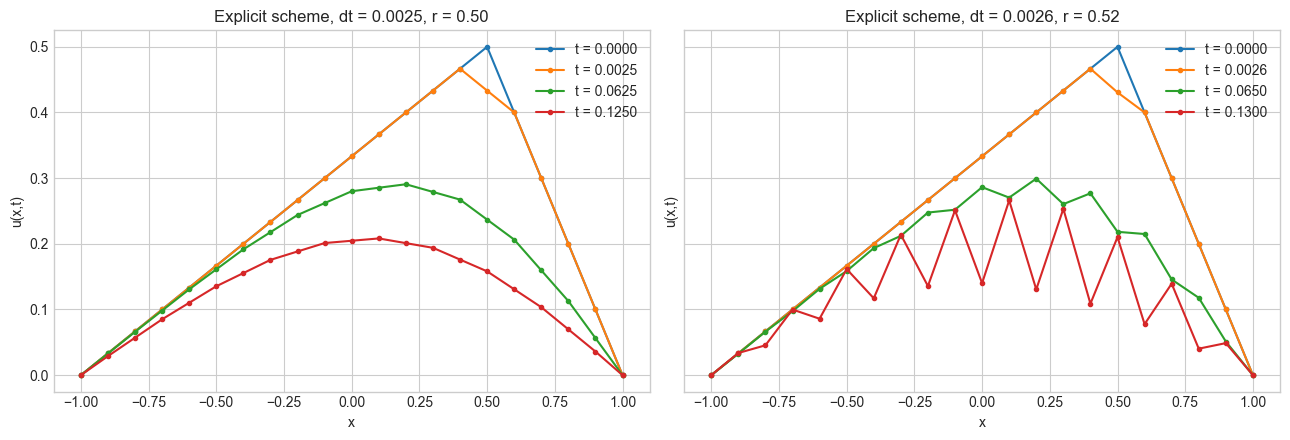

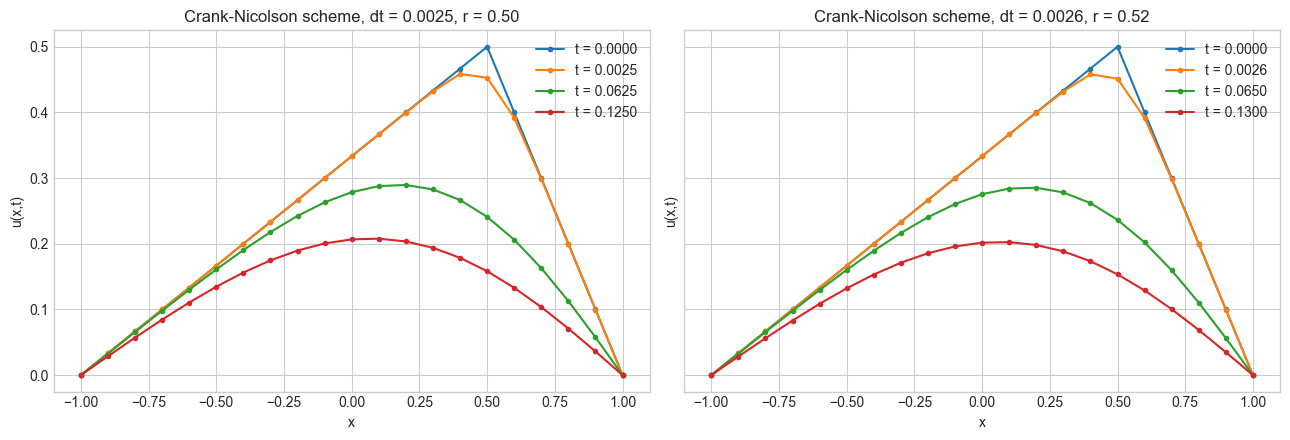

Explicit scheme: dt = 0.0025, r = 0.500
  Expected behavior: stable (at or below the stability threshold).
Explicit scheme: dt = 0.0026, r = 0.520
  Expected behavior: unstable because r = a*dt/dx^2 exceeds 0.5.
Crank-Nicolson scheme: dt = 0.0025, r = 0.500
  Expected behavior: unconditionally stable for this diffusion problem.
Crank-Nicolson scheme: dt = 0.0026, r = 0.520
  Expected behavior: unconditionally stable for this diffusion problem.


In [2]:
explicit_results = {dt: run_heat_explicit(dt) for dt in HEAT_DTS}
cn_results = {dt: run_heat_crank_nicolson(dt) for dt in HEAT_DTS}

plot_heat_snapshots("Explicit scheme", explicit_results)
plot_heat_snapshots("Crank-Nicolson scheme", cn_results)

for dt in HEAT_DTS:
    _, _, r = explicit_results[dt]
    print(f"Explicit scheme: dt = {dt}, r = {r:.3f}")
    if r <= 0.5:
        print("  Expected behavior: stable (at or below the stability threshold).")
    else:
        print("  Expected behavior: unstable because r = a*dt/dx^2 exceeds 0.5.")

for dt in HEAT_DTS:
    _, _, r = cn_results[dt]
    print(f"Crank-Nicolson scheme: dt = {dt}, r = {r:.3f}")
    print("  Expected behavior: unconditionally stable for this diffusion problem.")

### Summary of Part 1

For the explicit method, the stability condition is
$$
r = a\frac{dt}{dx^2} \le \frac{1}{2}.
$$
With $a=2$ and $dx=0.1$, this gives $dt \le 0.0025$. Therefore:
- `dt = 0.0025` is exactly at the stability limit.
- `dt = 0.0026` is slightly above the limit and should show instability.

The Crank-Nicolson method is unconditionally stable for this linear heat equation, so both time steps should remain well behaved. This part shows the expected contrast between a conditionally stable explicit scheme and a more robust implicit second-order method.

## Part 2: Linear Advection

Part 2 considers
$$
u_t + 1.8u_x = 0, \quad x \in (-2,2),
$$
with initial condition
$$
u_0(x)=\begin{cases}1, & x \le 0,\\0, & x > 0,\end{cases}
$$
and boundary conditions $u(-2,t)=1$ and $u(2,t)=0$.

The problem specifies $\nu = dt/dx = 0.25$. For each given $dt$, the grid spacing is chosen as
$$
dx = \frac{dt}{0.25}.
$$
The numerical solution is computed at $t = 0.5$ using the upwind method and the Lax-Wendroff method, and each result is compared with the exact translated step profile.

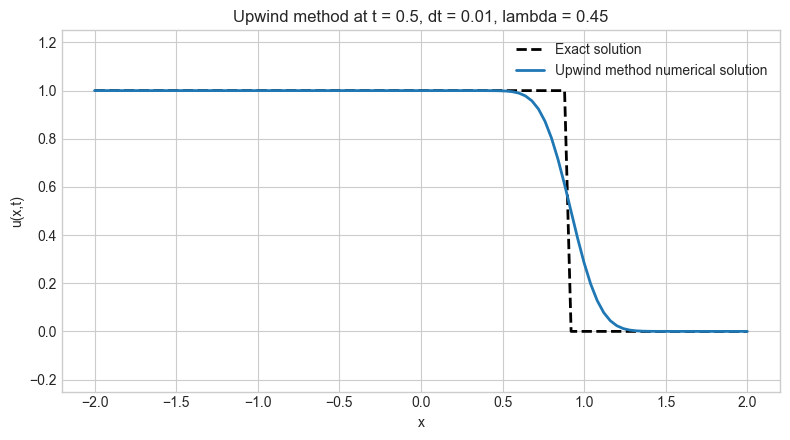

Upwind method: dt = 0.01, lambda = 0.45, max error = 0.4981


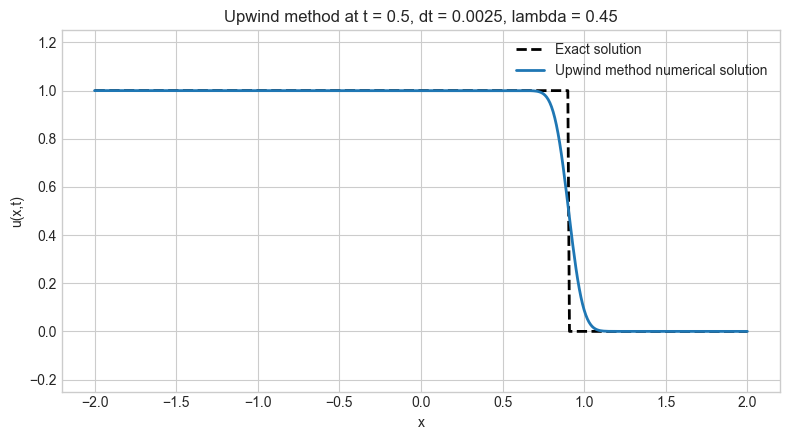

Upwind method: dt = 0.0025, lambda = 0.45, max error = 0.4726


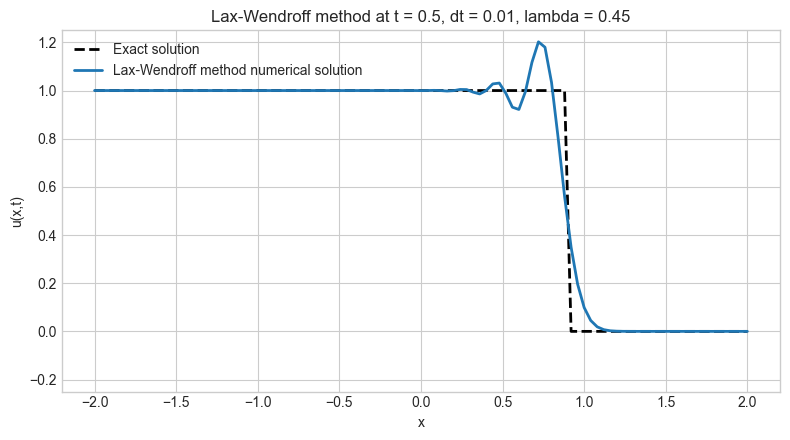

Lax-Wendroff method: dt = 0.01, lambda = 0.45, max error = 0.4391


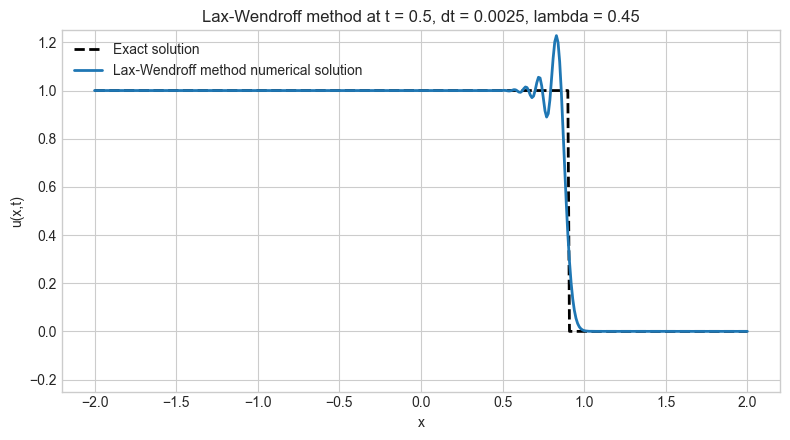

Lax-Wendroff method: dt = 0.0025, lambda = 0.45, max error = 0.5964


In [3]:
ADVECTION_DTS = [0.01, 0.0025]
C = 1.8
NU = 0.25
T_FINAL = 0.5


def advection_initial_condition(x):
    x = np.asarray(x)
    return np.where(x <= 0.0, 1.0, 0.0)


def advection_exact(x, t, c=C):
    x = np.asarray(x)
    return np.where(x - c * t <= 0.0, 1.0, 0.0)


def advection_grid(dt, nu=NU):
    dx = dt / nu
    n_intervals = int(round(4.0 / dx))
    x = np.linspace(-2.0, 2.0, n_intervals + 1)
    return x, x[1] - x[0]


def run_upwind(dt, nu=NU, c=C, t_final=T_FINAL):
    x, dx = advection_grid(dt, nu)
    lam = c * dt / dx
    u = advection_initial_condition(x)
    n_steps = int(round(t_final / dt))

    for _ in range(n_steps):
        u_new = u.copy()
        u_new[1:] = u[1:] - lam * (u[1:] - u[:-1])
        u_new[0] = 1.0
        u_new[-1] = 0.0
        u = u_new

    return x, u, lam


def run_lax_wendroff(dt, nu=NU, c=C, t_final=T_FINAL):
    x, dx = advection_grid(dt, nu)
    lam = c * dt / dx
    u = advection_initial_condition(x)
    n_steps = int(round(t_final / dt))

    for _ in range(n_steps):
        u_new = u.copy()
        u_new[1:-1] = (
            u[1:-1]
            - 0.5 * lam * (u[2:] - u[:-2])
            + 0.5 * lam**2 * (u[2:] - 2.0 * u[1:-1] + u[:-2])
        )
        u_new[0] = 1.0
        u_new[-1] = 0.0
        u = u_new

    return x, u, lam


def plot_advection_comparison(method_name, solver):
    for dt in ADVECTION_DTS:
        x, numerical, lam = solver(dt)
        exact = advection_exact(x, T_FINAL)

        plt.figure(figsize=(8, 4.5))
        plt.plot(x, exact, "k--", linewidth=2, label="Exact solution")
        plt.plot(x, numerical, color="tab:blue", linewidth=2, label=f"{method_name} numerical solution")
        plt.title(f"{method_name} at t = {T_FINAL}, dt = {dt}, lambda = {lam:.2f}")
        plt.xlabel("x")
        plt.ylabel("u(x,t)")
        plt.ylim(-0.25, 1.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

        max_error = np.max(np.abs(numerical - exact))
        print(f"{method_name}: dt = {dt}, lambda = {lam:.2f}, max error = {max_error:.4f}")


plot_advection_comparison("Upwind method", run_upwind)
plot_advection_comparison("Lax-Wendroff method", run_lax_wendroff)

### Summary of Part 2

The exact solution is a step that translates to the right with speed `1.8`, so at `t = 0.5` the jump is located at `x = 0.9`.

The upwind method is monotone and robust, but it is numerically diffusive, so the sharp jump is smeared over several grid points. The Lax-Wendroff method usually preserves the location of the jump more sharply, but it can introduce nonphysical oscillations near the discontinuity. Comparing `dt = 0.01` and `dt = 0.0025`, the smaller time step also gives a smaller `dx` because `dt/dx = 0.25` is fixed, so the spatial resolution is finer and the numerical solution should match the exact step more closely.

This part shows the usual trade-off for advection problems: the upwind method is more dissipative, while the Lax-Wendroff method is sharper but more oscillatory near discontinuities.